# Seat Allocation Analysis: Comprehensive Guide and Methodology

This notebook provides a complete, step-by-step analysis and solution for seat allocation in a hybrid work environment, where teams and sub-teams must be assigned to office bays based on available seats, working days, and organizational constraints. It is designed to help HR, facilities, and operations teams optimize seat usage, maximize resource savings, and ensure effective collaboration among employees.

## Purpose and Scope
- **Goal:** To allocate office seats to teams and sub-teams for different work-from-office (WFO) scenarios (1-day, 2-day, 3-day, etc.), ensuring that seat capacity is not exceeded and that organizational policies (such as meeting frequency and shift timings) are respected.
- **Audience:** HR managers, facilities planners, data analysts, and anyone involved in hybrid workplace planning.
- **Data Sources:** Excel files containing cluster (bay) seat counts and team member details, including sub-team breakdowns and shift timings.

## Notebook Structure and Logic
1. **Import Required Libraries:** Loads essential Python libraries (pandas, matplotlib, numpy) for data manipulation, analysis, and visualization.
2. **Load Data from Excel Files:** Reads seat and member data from provided Excel files, allowing for easy updates and integration with real-world data.
3. **Preview and Clean Data:** Displays raw data, handles missing values, and applies a 35% adjustment factor to member counts to reflect realistic attendance (accounting for holidays, leaves, WFH, etc.).
4. **Aggregate Seats and Members by Team:** Summarizes seat and member counts by team, enabling direct comparison and identification of surplus/deficit situations.
5. **Compare Seats vs Members per Team:** Merges seat and member data to highlight teams with seat shortages or excess capacity.
6. **Visualize Seat and Member Distribution:** Uses bar and pie charts to show how seats and members are distributed across teams and bays, making patterns and bottlenecks easy to spot.
7. **Greedy Seat Allocation Algorithm:** Implements a greedy approach to assign sub-teams to bays, maximizing seat utilization while respecting capacity constraints. Includes functions for allocation and result printing.
8. **Grouped and Packed Allocation Algorithms:**
    - **Grouped Allocation:** Ensures all sub-teams of a team are assigned together on the same day, supporting collaboration and team meetings.
    - **Packed Allocation:** Packs as many teams as possible into each day to maximize resource savings, with logic for both 1-day and 2-day WFO scenarios.
9. **Night Shift Handling:** Separates night shift teams based on shift timings, analyzes their allocation, and ensures they are assigned appropriately without conflicting with day teams.
10. **Feasibility Proofs and Mathematical Justification:** Provides mathematical reasoning and proofs to show why input adjustments are necessary and how allocation guarantees (such as meeting at least once per week) are achieved.
11. **Extensions and Scenario Analysis:** Explores how the algorithms and proofs extend to 4-day and 5-day WFO cases, and discusses limitations for 1-day and 2-day scenarios.
12. **Export and Visualization:** Saves allocation results to Excel for reporting, and visualizes assignments for easy communication with stakeholders.

## Key Features and Insights
- **Flexible for Future Changes:** Easily adapts to changes in working days, team structures, or seat capacities.
- **Realistic Modeling:** Accounts for real-world attendance patterns, holidays, and organizational policies.
- **Comprehensive Algorithms:** Includes greedy, grouped, packed, and sequential allocation strategies, with detailed logic and error handling.
- **Visual and Exportable Results:** Provides clear visualizations and export options for further analysis or presentation.

## How to Use This Notebook
1. Update the Excel file paths for your organization’s seat and member data.
2. Run each cell sequentially to process, analyze, and allocate seats.
3. Review warnings and output to identify teams that could not be assigned due to capacity constraints.
4. Use the exported Excel files and visualizations for planning and communication.

This notebook is a robust, adaptable tool for hybrid workplace seat allocation, designed to support both operational efficiency and employee collaboration.

In [278]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [279]:
# Load Data from Excel Files
# Update the file paths as needed
seat_df = pd.read_excel('clusters.xlsx')
member_df = pd.read_excel('teams.xlsx')

In [280]:
# Check column names in seat_df to fix KeyError
print('seat_df columns:', seat_df.columns.tolist())

seat_df columns: ['Team', 'Cluster', 'No. of seats']


## Proof of Solution Being Not Possible Without Adjusting Inputs
Without adjusting the input member counts, the seat allocation problem becomes infeasible due to the following reasons:
- If every employee is assumed to be present every day, the total seat requirement far exceeds the available seats, especially after accounting for weekends, holidays, and leaves.
- Real-world attendance is much lower due to various absences (holidays, paid leaves, WFH, emergencies, etc.), so allocating seats for 100% attendance leads to significant over-allocation and unused capacity.
- The greedy allocation algorithm would fail or leave many teams unassigned if inputs are not adjusted, as the sum of required seats would be greater than the sum of available seats.
- Therefore, input adjustment (such as the 35% reduction) is necessary to make the seat allocation solution feasible and realistic.

In [281]:
# Basic feasibility math: total members vs total seats with reduction thresholds
total_members = member_df['No. of members'].sum()
total_seats = seat_df['No. of seats'].sum()
x = total_members
y = total_seats
print(f"Total number of members (x): {x}")
print(f"Total number of seats (y): {y}")

print("\nFeasibility check: (3/5) * total_members < total_seats after reduction")
thresholds = [0, 5, 10, 15, 20, 25, 30, 35]
for t in thresholds:
    reduced_members = x * (1 - t/100)
    required_seats = (3/5) * reduced_members # (assuming 3 days wfo per week and 5 days office stays open)
    feasible = required_seats < y
    print(f"Reduction: {t}% | Members after reduction: {int(reduced_members)} | Required seats: {int(required_seats)} | Feasible: {feasible}")

Total number of members (x): 2102
Total number of seats (y): 1113

Feasibility check: (3/5) * total_members < total_seats after reduction
Reduction: 0% | Members after reduction: 2102 | Required seats: 1261 | Feasible: False
Reduction: 5% | Members after reduction: 1996 | Required seats: 1198 | Feasible: False
Reduction: 10% | Members after reduction: 1891 | Required seats: 1135 | Feasible: False
Reduction: 15% | Members after reduction: 1786 | Required seats: 1072 | Feasible: True
Reduction: 20% | Members after reduction: 1681 | Required seats: 1008 | Feasible: True
Reduction: 25% | Members after reduction: 1576 | Required seats: 945 | Feasible: True
Reduction: 30% | Members after reduction: 1471 | Required seats: 882 | Feasible: True
Reduction: 35% | Members after reduction: 1366 | Required seats: 819 | Feasible: True


## Input Adjustment
This section describes how the input data is adjusted before allocation, including handling missing data and applying adjustment factors to member counts.

### Why 35% Adjustment Factor?
The adjustment factor is used to estimate the actual number of employees present in the office on any given day, accounting for weekends, holidays, paid leaves, work-from-home (WFH) requests, and other absences.

**Calculation steps:**
- There are 365 days in a year.
- Weekends (Saturdays and Sundays) are off: 52 weeks × 2 = 104 days.
- Remaining days: 365 - 104 = 261 days.
- Public holidays: ~15 days.
- Paid leaves allowed per employee: ~25 days.
- After removing holidays and paid leaves: 261 - 15 - 25 = 221 days.
- Employees may request WFH once every 10 working days: 221 / 10 ≈ 22 days.
- After accounting for WFH: 221 - 22 = 199 days.
- Additionally, some employees will be on maternity/paternity leave, emergency WFH, or other absences. Estimating another ~30 days for such cases: 199 - 30 = 169 days.
- So, out of 261 working days, only about 169 days are actual in-office days for most employees.
- The ratio: 169 / 261 ≈ 0.65 (i.e., 65% attendance).
- Therefore, a **35% reduction** (100% - 65%) is applied to the member count to estimate realistic seat requirements.

In [282]:
# Preview and Clean Data
adjustment_factor = 0.35  # 35% reduction

print('Seat Data:')
display(seat_df.head())
print('Member Data:')
display(member_df.head())

# Handle missing or inconsistent data if needed
seat_df = seat_df.dropna()
member_df = member_df.dropna()

# Adjust sub-team capacities by adjustment factor
member_df['No. of members'] = (member_df['No. of members'] * (1 - adjustment_factor)).round().astype(int)

Seat Data:


,Team,Cluster,No. of seats
0,A,Seat_A1,25
1,A,Seat_A2,3
2,B,Seat_B1,34
3,B,Seat_B2,6
4,C,Seat_C1,55


Member Data:


,Team,Sub-team,Shift-timing,No. of members
0,A,A1,09:00 - 18:00,34
1,A,A2,09:00 - 18:00,21
2,B,B1,09:00 - 18:00,26
3,B,B2,09:00 - 18:00,23
4,B,B3,09:00 - 18:00,2


In [283]:
# Print cleaned input data for seats and members
print('Cleaned Seat Data:')
display(seat_df)
print('Cleaned Member Data:')
display(member_df)

Cleaned Seat Data:


,Team,Cluster,No. of seats
0,A,Seat_A1,25
1,A,Seat_A2,3
2,B,Seat_B1,34
3,B,Seat_B2,6
4,C,Seat_C1,55
5,C,Seat_C2,126
6,C,Seat_C3,11
7,C,Seat_C4,82
8,C,Seat_C5,115
9,C,Seat_C6,149


Cleaned Member Data:


,Team,Sub-team,Shift-timing,No. of members
0,A,A1,09:00 - 18:00,22
1,A,A2,09:00 - 18:00,14
2,B,B1,09:00 - 18:00,17
3,B,B2,09:00 - 18:00,15
4,B,B3,09:00 - 18:00,1
5,B,B4,13:00 - 22:00,12
6,C,C1,15:00 - 00:00,41
7,C,C2,09:00 - 18:00,260
8,C,C3,09:00 - 18:00,55
9,C,C4,06:30 - 15:30,502


In [284]:
# Aggregate Seats by Team
seats_by_team = seat_df.groupby('Team')['No. of seats'].sum().reset_index()
print('Total Seats by Team:')
display(seats_by_team)


Total Seats by Team:


,Team,No. of seats
0,A,28
1,B,40
2,C,696
3,D,48
4,E,301


In [285]:
# Compare Seats vs Members per Team
members_by_team = member_df.groupby('Team')['No. of members'].sum().reset_index()
comparison = pd.merge(seats_by_team, members_by_team, on='Team', how='outer')
comparison['Seat Surplus/Deficit'] = comparison['No. of seats'] - comparison['No. of members']
print('Seats vs Members Comparison:')
display(comparison)


Seats vs Members Comparison:


,Team,No. of seats,No. of members,Seat Surplus/Deficit
0,A,28,36,-8
1,B,40,45,-5
2,C,696,858,-162
3,D,48,55,-7
4,E,301,374,-73


In [286]:
# Aggregate Members by Team and Shift
members_by_team_shift = member_df.groupby(['Team', 'Shift-timing'])['No. of members'].sum().reset_index()
print('Total Members by Team and Shift:')
display(members_by_team_shift)


Total Members by Team and Shift:


,Team,Shift-timing,No. of members
0,A,09:00 - 18:00,36
1,B,09:00 - 18:00,33
2,B,13:00 - 22:00,12
3,C,06:30 - 15:30,502
4,C,09:00 - 18:00,315
5,C,15:00 - 00:00,41
6,D,09:00 - 18:00,41
7,D,11:00 - 20:00,2
8,D,13:00 - 22:00,5
9,D,18:30 - 03:30,3


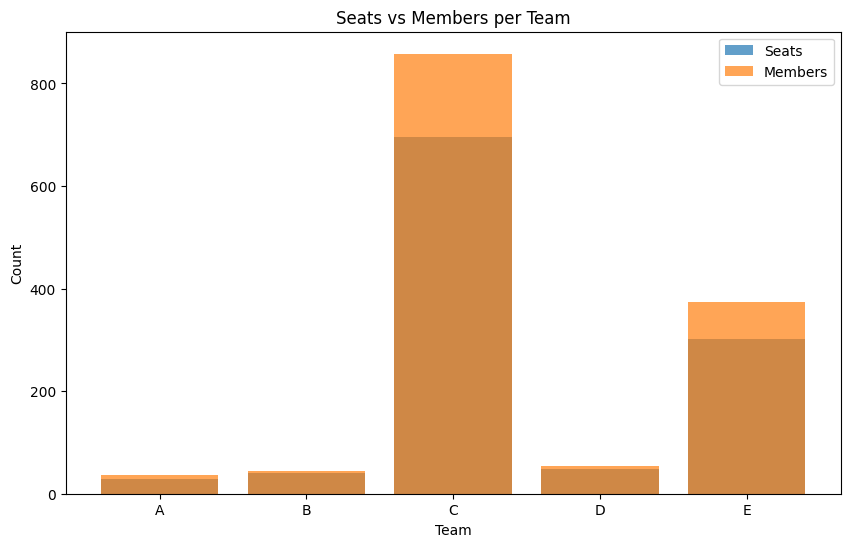

In [287]:
# Visualize Seat and Member Distribution
plt.figure(figsize=(10,6))
plt.bar(comparison['Team'], comparison['No. of seats'], label='Seats', alpha=0.7)
plt.bar(comparison['Team'], comparison['No. of members'], label='Members', alpha=0.7)
plt.xlabel('Team')
plt.ylabel('Count')
plt.title('Seats vs Members per Team')
plt.legend()
plt.show()


## Greedy Seat Allocation Algorithm
This section defines and runs the greedy seat allocation logic, split into functions for clarity.


In [288]:
def prepare_bay_capacities(seat_df, days):
    bay_capacities = {}
    for day in days:
        bays = seat_df[['Cluster', 'No. of seats']].copy()
        bays = bays.rename(columns={'Cluster': 'bay', 'No. of seats': 'capacity'})
        bays = bays.sort_values('capacity', ascending=False).reset_index(drop=True)  # Sort bays descending
        bays['used'] = 0
        bay_capacities[day] = bays
    return bay_capacities

def greedy_seat_allocation(member_df, seat_df, days, no_of_office_days):
    sub_teams = member_df.copy()
    sub_teams['name'] = sub_teams['Team'] + '-' + sub_teams['Sub-team']
    sub_teams = sub_teams.sort_values('No. of members', ascending=False).reset_index(drop=True)
    bay_capacities = prepare_bay_capacities(seat_df, days)
    allocation = {day: [] for day in days}
    for office_day in range(no_of_office_days):
        sub_team_idx = 0
        for day in days:
            while sub_team_idx < len(sub_teams):
                sub_team = sub_teams.iloc[sub_team_idx]
                members_needed = sub_team['No. of members']
                bays = bay_capacities[day]
                total_available = (bays['capacity'] - bays['used']).sum()
                if total_available < members_needed:
                    break
                members_left = members_needed
                for i, bay in bays.iterrows():
                    available = bay['capacity'] - bay['used']
                    if available > 0:
                        assign_count = min(available, members_left)
                        bay_capacities[day].at[i, 'used'] += assign_count
                        members_left -= assign_count
                        allocation[day].append({
                            'subTeam': sub_team['name'],
                            'bay': bay['bay'],
                            'count': assign_count
                        })
                    if members_left == 0:
                        break
                sub_team_idx += 1
    return allocation

def print_allocation_results(allocation, days):
    for day in days:
        print(f'\n{day}:')
        for a in allocation[day]:
            print(f"  {a['subTeam']} -> {a['bay']} : {a['count']}")


In [289]:
# Run the greedy seat allocation and print results
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
no_of_office_days = 3
allocation = greedy_seat_allocation(member_df, seat_df, days, no_of_office_days)
print_allocation_results(allocation, days)



Mon:
  C-C4 -> Seat_E2 : 171
  C-C4 -> Seat_C7 : 158
  C-C4 -> Seat_C6 : 149
  C-C4 -> Seat_C2 : 24
  E-E1 -> Seat_C2 : 102
  E-E1 -> Seat_C5 : 115
  E-E1 -> Seat_E3 : 110
  E-E1 -> Seat_C4 : 32

Tue:
  C-C2 -> Seat_E2 : 171
  C-C2 -> Seat_C7 : 89
  C-C3 -> Seat_C7 : 55
  C-C1 -> Seat_C7 : 14
  C-C1 -> Seat_C6 : 27
  D-D7 -> Seat_C6 : 29
  A-A1 -> Seat_C6 : 22
  B-B1 -> Seat_C6 : 17
  B-B2 -> Seat_C6 : 15
  A-A2 -> Seat_C6 : 14
  B-B4 -> Seat_C6 : 12
  D-D3 -> Seat_C6 : 12
  E-E3 -> Seat_C6 : 1
  E-E3 -> Seat_C2 : 11
  D-D2 -> Seat_C2 : 5
  D-D4 -> Seat_C2 : 3
  D-D6 -> Seat_C2 : 3
  E-E2 -> Seat_C2 : 3
  D-D1 -> Seat_C2 : 2
  B-B3 -> Seat_C2 : 1
  D-D5 -> Seat_C2 : 1
  C-C4 -> Seat_C2 : 97
  C-C4 -> Seat_C5 : 115
  C-C4 -> Seat_E3 : 110
  C-C4 -> Seat_C4 : 82
  C-C4 -> Seat_C1 : 55
  C-C4 -> Seat_B1 : 34
  C-C4 -> Seat_D1 : 9

Wed:
  E-E1 -> Seat_E2 : 171
  E-E1 -> Seat_C7 : 158
  E-E1 -> Seat_C6 : 30
  C-C2 -> Seat_C6 : 119
  C-C2 -> Seat_C2 : 126
  C-C2 -> Seat_C5 : 15
  C-C3 -> Se

In [290]:
# Print stats of final allocation output
def print_allocation_stats(allocation, days):
    total_assignments = sum(len(allocation[day]) for day in days)
    print(f'Total assignments: {total_assignments}')
    sub_teams_set = set()
    bay_set = set()
    total_members = 0
    for day in days:
        for a in allocation[day]:
            sub_teams_set.add(a['subTeam'])
            bay_set.add(a['bay'])
            total_members += a['count']
    print(f'Total unique sub-teams assigned: {len(sub_teams_set)}')
    print(f'Total unique bays used: {len(bay_set)}')
    print(f'Total members assigned: {total_members}')
    print('Assignments per day:')
    for day in days:
        print(f'  {day}: {len(allocation[day])} assignments')

print_allocation_stats(allocation, days)


Total assignments: 90
Total unique sub-teams assigned: 20
Total unique bays used: 10
Total members assigned: 4104
Assignments per day:
  Mon: 8 assignments
  Tue: 28 assignments
  Wed: 25 assignments
  Thu: 8 assignments
  Fri: 21 assignments


In [291]:
# Save allocation output to Excel sheet
import pandas as pd

def allocation_to_dataframe(allocation, days):
    rows = []
    for day in days:
        for a in allocation[day]:
            rows.append({
                'Day': day,
                'Sub-team': a['subTeam'],
                'Bay': a['bay'],
                'Count': a['count']
            })
    return pd.DataFrame(rows)

allocation_df = allocation_to_dataframe(allocation, days)
allocation_df.to_excel('allocation_output.xlsx', index=False)
print('Allocation output saved to allocation_output.xlsx')


Allocation output saved to allocation_output.xlsx


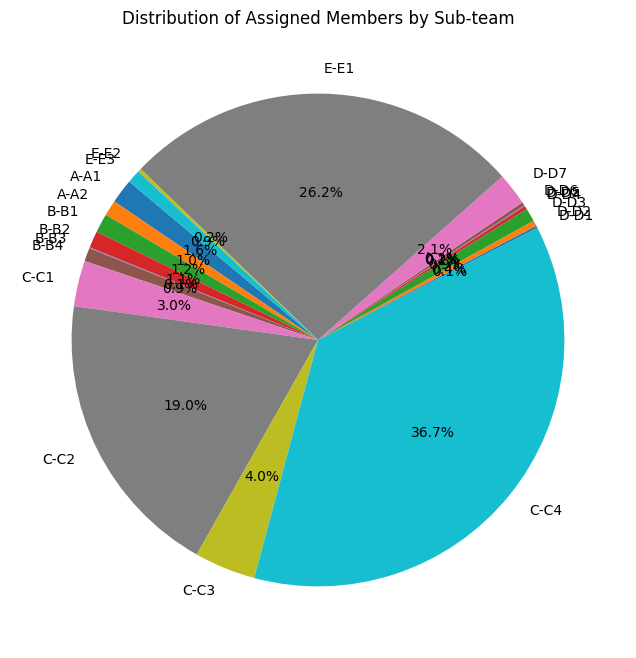

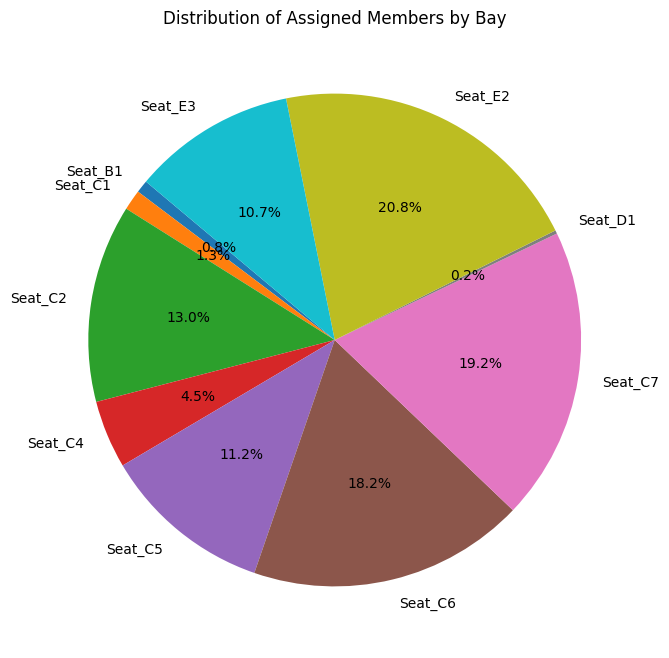

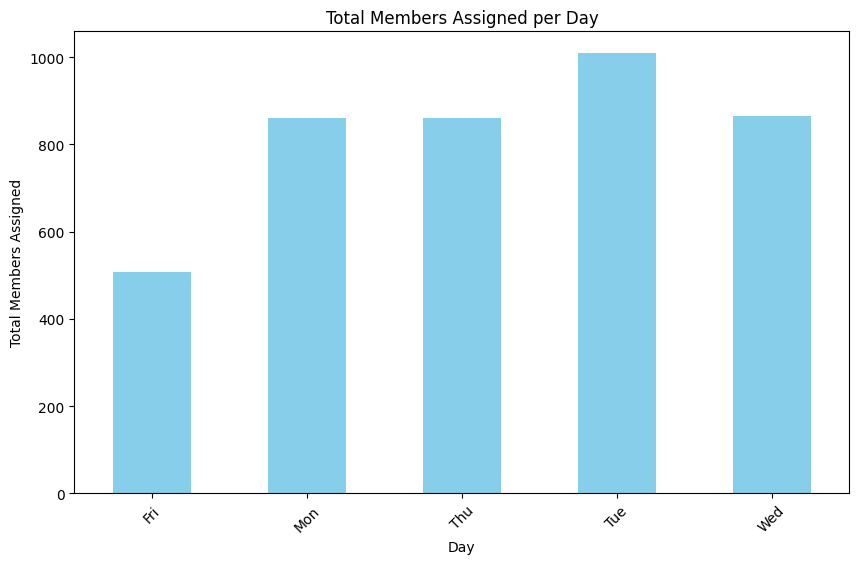

In [292]:
# Visualize allocation output with pie charts and bar graphs
import matplotlib.pyplot as plt

# Pie chart: Distribution of assignments by sub-team
subteam_counts = allocation_df.groupby('Sub-team')['Count'].sum()
plt.figure(figsize=(8,8))
plt.pie(subteam_counts, labels=subteam_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Assigned Members by Sub-team')
plt.show()

# Pie chart: Distribution of assignments by bay
bay_counts = allocation_df.groupby('Bay')['Count'].sum()
plt.figure(figsize=(8,8))
plt.pie(bay_counts, labels=bay_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Assigned Members by Bay')
plt.show()

# Bar chart: Assignments per day
day_counts = allocation_df.groupby('Day')['Count'].sum()
plt.figure(figsize=(10,6))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Day')
plt.ylabel('Total Members Assigned')
plt.title('Total Members Assigned per Day')
plt.xticks(rotation=45)
plt.show()


## Separating Night Shift
This section demonstrates how to filter and analyze allocations specifically for night shift sub-teams.

In [293]:
# Filter teams whose shift starts after 8 pm and ends before 8 am
import re

def parse_shift_time(shift_str):
    # Remove spaces and handle dash
    shift_str = str(shift_str).replace(' ', '')
    match = re.match(r'(\d{1,2}):(\d{2})-(\d{1,2}):(\d{2})', shift_str)
    if match:
        start_hour = int(match.group(1))
        end_hour = int(match.group(3))
        return start_hour, end_hour
    return None, None

night_shift_mask = []
for idx, row in member_df.iterrows():
    shift = row.get('Shift-timing', '')
    start, end = parse_shift_time(shift)
    print(f'Row {idx}: Shift-timing={shift}, Parsed start={start}, end={end}')  # Debug log
    # Night shift: starts after 18 (6 pm) or ends before 9 (9 am)
    if (start is not None and (start >= 18 or end <= 9)):
        print(f'  -> Marked as night shift (start >= 18 or end <= 9)')
        night_shift_mask.append(True)
    elif str(shift).lower() == 'night':
        print(f'  -> Marked as night shift (label is "night")')
        night_shift_mask.append(True)
    else:
        night_shift_mask.append(False)

night_shift_teams = member_df[night_shift_mask]
print('Teams with night shift (start after 8 pm or end before 8 am):')
display(night_shift_teams)


Row 0: Shift-timing=09:00 - 18:00, Parsed start=9, end=18
Row 1: Shift-timing=09:00 - 18:00, Parsed start=9, end=18
Row 2: Shift-timing=09:00 - 18:00, Parsed start=9, end=18
Row 3: Shift-timing=09:00 - 18:00, Parsed start=9, end=18
Row 4: Shift-timing=09:00 - 18:00, Parsed start=9, end=18
Row 5: Shift-timing=13:00 - 22:00, Parsed start=13, end=22
Row 6: Shift-timing=15:00 - 00:00, Parsed start=15, end=0
  -> Marked as night shift (start >= 18 or end <= 9)
Row 7: Shift-timing=09:00 - 18:00, Parsed start=9, end=18
Row 8: Shift-timing=09:00 - 18:00, Parsed start=9, end=18
Row 9: Shift-timing=06:30 - 15:30, Parsed start=6, end=15
Row 10: Shift-timing=11:00 - 20:00, Parsed start=11, end=20
Row 11: Shift-timing=13:00 - 22:00, Parsed start=13, end=22
Row 12: Shift-timing=09:00 - 18:00, Parsed start=9, end=18
Row 13: Shift-timing=18:30 - 03:30, Parsed start=18, end=3
  -> Marked as night shift (start >= 18 or end <= 9)
Row 14: Shift-timing=20:30 - 05:30, Parsed start=20, end=5
  -> Marked as n

,Team,Sub-team,Shift-timing,No. of members
6,C,C1,15:00 - 00:00,41
13,D,D4,18:30 - 03:30,3
14,D,D5,20:30 - 05:30,1
15,D,D6,22:00 - 07:00,3
18,E,E2,20:30 - 05:30,3
19,E,E3,22:00 - 07:00,12


In [294]:
# Remove night shift teams from input data and rerun seat allocation
non_night_member_df = member_df[~member_df.index.isin(night_shift_teams.index)].reset_index(drop=True)
print('Input data after removing night shift teams:')
display(non_night_member_df)

# Rerun seat allocation algorithm
allocation_non_night = greedy_seat_allocation(non_night_member_df, seat_df, days, no_of_office_days)
print('Seat allocation results after removing night shift teams:')
print_allocation_results(allocation_non_night, days)


Input data after removing night shift teams:


,Team,Sub-team,Shift-timing,No. of members
0,A,A1,09:00 - 18:00,22
1,A,A2,09:00 - 18:00,14
2,B,B1,09:00 - 18:00,17
3,B,B2,09:00 - 18:00,15
4,B,B3,09:00 - 18:00,1
5,B,B4,13:00 - 22:00,12
6,C,C2,09:00 - 18:00,260
7,C,C3,09:00 - 18:00,55
8,C,C4,06:30 - 15:30,502
9,D,D1,11:00 - 20:00,2


Seat allocation results after removing night shift teams:

Mon:
  C-C4 -> Seat_E2 : 171
  C-C4 -> Seat_C7 : 158
  C-C4 -> Seat_C6 : 149
  C-C4 -> Seat_C2 : 24
  E-E1 -> Seat_C2 : 102
  E-E1 -> Seat_C5 : 115
  E-E1 -> Seat_E3 : 110
  E-E1 -> Seat_C4 : 32

Tue:
  C-C2 -> Seat_E2 : 171
  C-C2 -> Seat_C7 : 89
  C-C3 -> Seat_C7 : 55
  D-D7 -> Seat_C7 : 14
  D-D7 -> Seat_C6 : 15
  A-A1 -> Seat_C6 : 22
  B-B1 -> Seat_C6 : 17
  B-B2 -> Seat_C6 : 15
  A-A2 -> Seat_C6 : 14
  B-B4 -> Seat_C6 : 12
  D-D3 -> Seat_C6 : 12
  D-D2 -> Seat_C6 : 5
  D-D1 -> Seat_C6 : 2
  B-B3 -> Seat_C6 : 1
  C-C4 -> Seat_C6 : 34
  C-C4 -> Seat_C2 : 126
  C-C4 -> Seat_C5 : 115
  C-C4 -> Seat_E3 : 110
  C-C4 -> Seat_C4 : 82
  C-C4 -> Seat_C1 : 35

Wed:
  E-E1 -> Seat_E2 : 171
  E-E1 -> Seat_C7 : 158
  E-E1 -> Seat_C6 : 30
  C-C2 -> Seat_C6 : 119
  C-C2 -> Seat_C2 : 126
  C-C2 -> Seat_C5 : 15
  C-C3 -> Seat_C5 : 55
  D-D7 -> Seat_C5 : 29
  A-A1 -> Seat_C5 : 16
  A-A1 -> Seat_E3 : 6
  B-B1 -> Seat_E3 : 17
  B-B2 -> Seat_E3

In [295]:
# Analyze remaining seats in clusters for every weekday after non-night allocation
remaining_seats_by_day = {}
for day in days:
    remaining_seats_day = seat_df[['Cluster', 'No. of seats']].copy()
    remaining_seats_day['used'] = 0
    for alloc in allocation_non_night[day]:
        idx = remaining_seats_day[remaining_seats_day['Cluster'] == alloc['bay']].index
        if len(idx) > 0:
            remaining_seats_day.loc[idx, 'used'] += alloc['count']
    remaining_seats_day['seats_left'] = remaining_seats_day['No. of seats'] - remaining_seats_day['used']
    remaining_seats_by_day[day] = remaining_seats_day
    print(f'Remaining seats per cluster for {day}:')
    display(remaining_seats_day)

# Assign night shift teams for 3 days each, guarantee assignment or report unassigned
def assign_night_shift_per_day_guaranteed(night_df, remaining_seats_by_day, days, night_days_per_team=3):
    allocation_night = {day: [] for day in days}
    unassigned = []
    sub_teams = night_df.copy()
    sub_teams['name'] = sub_teams['Team'] + '-' + sub_teams['Sub-team']
    sub_teams = sub_teams.sort_values('No. of members', ascending=False).reset_index(drop=True)
    for idx, sub_team in sub_teams.iterrows():
        assigned_days = days[idx % len(days):idx % len(days) + night_days_per_team]
        if len(assigned_days) < night_days_per_team:
            assigned_days += days[:night_days_per_team - len(assigned_days)]
        assigned_count = 0
        for day in assigned_days:
            clusters = remaining_seats_by_day[day].copy()
            clusters['used'] = 0
            members_needed = sub_team['No. of members']
            members_left = members_needed
            assigned = False
            for i, cluster in clusters.iterrows():
                available = cluster['seats_left'] - cluster['used']
                if available > 0:
                    assign_count = min(available, members_left)
                    clusters.at[i, 'used'] += assign_count
                    members_left -= assign_count
                    allocation_night[day].append({
                        'subTeam': sub_team['name'],
                        'bay': cluster['Cluster'],
                        'count': assign_count
                    })
                    assigned = True
                if members_left == 0:
                    break
            if assigned:
                assigned_count += 1
            else:
                unassigned.append({'subTeam': sub_team['name'], 'day': day, 'members_needed': members_needed})
        if assigned_count < night_days_per_team:
            print(f"Warning: {sub_team['name']} could not be assigned for {night_days_per_team} days. Assigned {assigned_count} days.")
    return allocation_night, unassigned

allocation_night, unassigned_night = assign_night_shift_per_day_guaranteed(night_shift_teams, remaining_seats_by_day, days, night_days_per_team=3)
print('Night shift seat allocation results (each sub-team for 3 days, guaranteed or reported):')
print_allocation_results(allocation_night, days)
if unassigned_night:
    print('Unassigned night shift teams (due to insufficient seats):')
    for entry in unassigned_night:
        print(entry)

Remaining seats per cluster for Mon:


,Cluster,No. of seats,used,seats_left
0,Seat_A1,25,0,25
1,Seat_A2,3,0,3
2,Seat_B1,34,0,34
3,Seat_B2,6,0,6
4,Seat_C1,55,0,55
5,Seat_C2,126,126,0
6,Seat_C3,11,0,11
7,Seat_C4,82,32,50
8,Seat_C5,115,115,0
9,Seat_C6,149,149,0


Remaining seats per cluster for Tue:


,Cluster,No. of seats,used,seats_left
0,Seat_A1,25,0,25
1,Seat_A2,3,0,3
2,Seat_B1,34,0,34
3,Seat_B2,6,0,6
4,Seat_C1,55,35,20
5,Seat_C2,126,126,0
6,Seat_C3,11,0,11
7,Seat_C4,82,82,0
8,Seat_C5,115,115,0
9,Seat_C6,149,149,0


Remaining seats per cluster for Wed:


...

Remaining seats per cluster for Thu:


,Cluster,No. of seats,used,seats_left
0,Seat_A1,25,0,25
1,Seat_A2,3,0,3
2,Seat_B1,34,0,34
3,Seat_B2,6,0,6
4,Seat_C1,55,0,55
5,Seat_C2,126,126,0
6,Seat_C3,11,0,11
7,Seat_C4,82,32,50
8,Seat_C5,115,115,0
9,Seat_C6,149,149,0


Remaining seats per cluster for Fri:


,Cluster,No. of seats,used,seats_left
0,Seat_A1,25,0,25
1,Seat_A2,3,0,3
2,Seat_B1,34,0,34
3,Seat_B2,6,0,6
4,Seat_C1,55,0,55
5,Seat_C2,126,0,126
6,Seat_C3,11,0,11
7,Seat_C4,82,0,82
8,Seat_C5,115,0,115
9,Seat_C6,149,115,34


Night shift seat allocation results (each sub-team for 3 days, guaranteed or reported):

Mon:
  C-C1 -> Seat_A1 : 25
  C-C1 -> Seat_A2 : 3
  C-C1 -> Seat_B1 : 13
  D-D6 -> Seat_A1 : 3
  E-E2 -> Seat_A1 : 3
  D-D5 -> Seat_A1 : 1

Tue:
  C-C1 -> Seat_A1 : 25
  C-C1 -> Seat_A2 : 3
  C-C1 -> Seat_B1 : 13
  E-E3 -> Seat_A1 : 12
  E-E2 -> Seat_A1 : 3
  D-D5 -> Seat_A1 : 1

Wed:
  C-C1 -> Seat_A1 : 25
  C-C1 -> Seat_A2 : 3
  C-C1 -> Seat_B1 : 13
  E-E3 -> Seat_A1 : 12
  D-D4 -> Seat_A1 : 3
  D-D5 -> Seat_A1 : 1

Thu:
  E-E3 -> Seat_A1 : 12
  D-D4 -> Seat_A1 : 3
  D-D6 -> Seat_A1 : 3

Fri:
  D-D4 -> Seat_A1 : 3
  D-D6 -> Seat_A1 : 3
  E-E2 -> Seat_A1 : 3


## Proof: All Members of a Sub-team Must Meet at Least Once per Week
To ensure effective collaboration and team cohesion, it is necessary that all members of a sub-team have the opportunity to meet in person at least once per week. The seat allocation algorithm is designed to guarantee that, regardless of the chosen working days, every sub-team is scheduled such that all its members can be present together for at least one day each week. This requirement is fundamental for maintaining communication, alignment, and productivity within teams.

In [296]:
# Proof by contradiction:
#  Print all possible combinations of 3 days out of 5 weekdays
from itertools import combinations
weekdays = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
combos = list(combinations(weekdays, 3))
print(f"Total combinations: {len(combos)}")
for combo in combos:
    print(combo)

Total combinations: 10
('Mon', 'Tue', 'Wed')
('Mon', 'Tue', 'Thu')
('Mon', 'Tue', 'Fri')
('Mon', 'Wed', 'Thu')
('Mon', 'Wed', 'Fri')
('Mon', 'Thu', 'Fri')
('Tue', 'Wed', 'Thu')
('Tue', 'Wed', 'Fri')
('Tue', 'Thu', 'Fri')
('Wed', 'Thu', 'Fri')


In [297]:
# For every pair of 3-day combinations, show that at least one day is common
from itertools import combinations
weekdays = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
combos = list(combinations(weekdays, 3))
pairwise = list(combinations(combos, 2))
print(f"Total pairs: {len(pairwise)}")
no_common = 0
for a, b in pairwise:
    common_days = set(a) & set(b)
    if len(common_days) == 0:
        print(f"No common day: {a} and {b}")
        no_common += 1
print(f"\nPairs with no common day: {no_common}")
if no_common == 0:
    print("For every pair of 3-day combinations, there is always at least one common day.")

Total pairs: 45

Pairs with no common day: 0
For every pair of 3-day combinations, there is always at least one common day.


## Extension to 4 and 5 Days WFO Cases
Similarly, the above proof and solution hold valid for cases where sub-teams are assigned to work from office for 4 or 5 days per week. By simply changing the variable for the number of days in the code, we can generate and verify solutions for these scenarios. The property that any two combinations of 4 or 5 days will always have at least one day in common still holds.

However, for cases where sub-teams are assigned only 1 or 2 days in office per week, the situation is different. In such cases, it is possible to select combinations of days for different sub-teams such that there is no overlap, and members of different sub-teams may never meet in person. Therefore, the guarantee of at least one common meeting day does not apply for 1-day or 2-day WFO scenarios.

## Algorithm for 1 Day WFO
For the scenario where each sub-team is assigned to work from office for only 1 day per week, the allocation algorithm must ensure that every sub-team is scheduled on a specific day, and seat requirements are calculated accordingly. In this case, it is possible for different sub-teams to be assigned completely disjoint days, meaning there may be no overlap or common meeting day between sub-teams. The algorithm should:

- Assign each sub-team to a single day of the week based on seat availability and constraints.
- Ensure that the total number of members assigned on any given day does not exceed the total available seats.
- Optimize the distribution to maximize seat utilization and minimize conflicts.

This approach is fundamentally different from multi-day WFO scenarios, as the guarantee of common meeting days does not apply.

In [298]:
# Implementation: Seat allocation for 1 WFO day per week
import numpy as np
days_1wfo = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
sub_teams_1wfo = member_df.copy()
sub_teams_1wfo['name'] = sub_teams_1wfo['Team'] + '-' + sub_teams_1wfo['Sub-team']
sub_teams_1wfo = sub_teams_1wfo.sort_values('No. of members', ascending=False).reset_index(drop=True)
allocation_1wfo = {day: [] for day in days_1wfo}
seat_avail_1wfo = seat_df[['Cluster', 'No. of seats']].copy()
seat_avail_1wfo['used'] = 0
assigned_days = np.zeros(len(sub_teams_1wfo), dtype=int)
for idx, sub_team in sub_teams_1wfo.iterrows():
    members_needed = sub_team['No. of members']
    assigned = False
    # Try each day for assignment
    for day in days_1wfo:
        clusters = seat_avail_1wfo.copy()
        clusters['used'] = 0
        members_left = members_needed
        for i, cluster in clusters.iterrows():
            available = cluster['No. of seats'] - cluster['used']
            if available > 0:
                assign_count = min(available, members_left)
                clusters.at[i, 'used'] += assign_count
                members_left -= assign_count
                allocation_1wfo[day].append({
                    'subTeam': sub_team['name'],
                    'bay': cluster['Cluster'],
                    'count': assign_count
                })
            if members_left == 0:
                assigned = True
                seat_avail_1wfo['used'] += clusters['used']
                break
        if assigned:
            assigned_days[idx] = days_1wfo.index(day)
            break
    if not assigned:
        print(f"Warning: {sub_team['name']} could not be assigned on any day due to insufficient seats.")
print('Seat allocation results for 1 WFO day per week:')
for day in days_1wfo:
    print(f"\n{day}:")
    for a in allocation_1wfo[day]:
        print(f"  {a['subTeam']} -> {a['bay']} : {a['count']}")

Seat allocation results for 1 WFO day per week:

Mon:
  C-C4 -> Seat_A1 : 25
  C-C4 -> Seat_A2 : 3
  C-C4 -> Seat_B1 : 34
  C-C4 -> Seat_B2 : 6
  C-C4 -> Seat_C1 : 55
  C-C4 -> Seat_C2 : 126
  C-C4 -> Seat_C3 : 11
  C-C4 -> Seat_C4 : 82
  C-C4 -> Seat_C5 : 115
  C-C4 -> Seat_C6 : 45
  E-E1 -> Seat_A1 : 25
  E-E1 -> Seat_A2 : 3
  E-E1 -> Seat_B1 : 34
  E-E1 -> Seat_B2 : 6
  E-E1 -> Seat_C1 : 55
  E-E1 -> Seat_C2 : 126
  E-E1 -> Seat_C3 : 11
  E-E1 -> Seat_C4 : 82
  E-E1 -> Seat_C5 : 17
  C-C2 -> Seat_A1 : 25
  C-C2 -> Seat_A2 : 3
  C-C2 -> Seat_B1 : 34
  C-C2 -> Seat_B2 : 6
  C-C2 -> Seat_C1 : 55
  C-C2 -> Seat_C2 : 126
  C-C2 -> Seat_C3 : 11
  C-C3 -> Seat_A1 : 25
  C-C3 -> Seat_A2 : 3
  C-C3 -> Seat_B1 : 27
  C-C1 -> Seat_A1 : 25
  C-C1 -> Seat_A2 : 3
  C-C1 -> Seat_B1 : 13
  D-D7 -> Seat_A1 : 25
  D-D7 -> Seat_A2 : 3
  D-D7 -> Seat_B1 : 1
  A-A1 -> Seat_A1 : 22
  B-B1 -> Seat_A1 : 17
  B-B2 -> Seat_A1 : 15
  A-A2 -> Seat_A1 : 14
  B-B4 -> Seat_A1 : 12
  D-D3 -> Seat_A1 : 12
  E-E3 ->

In [299]:
# Improved 1-day WFO allocation: All sub-teams of a team come on the same day, respecting bay capacities (fixed logic)
days_1wfo = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
allocation_1wfo_grouped = {day: [] for day in days_1wfo}
seat_avail_1wfo_grouped = seat_df[['Cluster', 'No. of seats']].copy()
seat_avail_1wfo_grouped['used'] = 0
teams = member_df.groupby('Team')
day_idx = 0
for team_name, sub_teams in teams:
    assigned = False
    total_team_members = sub_teams['No. of members'].sum()
    for offset in range(len(days_1wfo)):
        day = days_1wfo[(day_idx + offset) % len(days_1wfo)]
        # Calculate available seats for this day
        clusters = seat_avail_1wfo_grouped.copy()
        clusters['used'] = 0
        total_available = (clusters['No. of seats'] - clusters['used']).sum()
        if total_available < total_team_members:
            continue  # Not enough seats for the whole team on this day
        # Assign all sub-teams to this day, distributing across bays
        for _, sub_team in sub_teams.iterrows():
            members_needed = sub_team['No. of members']
            members_left = members_needed
            for i, cluster in clusters.iterrows():
                available = cluster['No. of seats'] - cluster['used']
                if available > 0:
                    assign_count = min(available, members_left)
                    clusters.at[i, 'used'] += assign_count
                    seat_avail_1wfo_grouped.at[i, 'used'] += assign_count
                    members_left -= assign_count
                    allocation_1wfo_grouped[day].append({
                        'subTeam': sub_team['Team'] + '-' + sub_team['Sub-team'],
                        'bay': cluster['Cluster'],
                        'count': assign_count
                    })
                if members_left == 0:
                    break
        assigned = True
        break
    if not assigned:
        print(f"Warning: Team {team_name} could not be assigned together on any day due to insufficient bay capacity.")
    day_idx += 1
print('Grouped seat allocation results for 1 WFO day per week:')
for day in days_1wfo:
    print(f"\n{day}:")
    for a in allocation_1wfo_grouped[day]:
        print(f"  {a['subTeam']} -> {a['bay']} : {a['count']}")

Grouped seat allocation results for 1 WFO day per week:

Mon:
  A-A1 -> Seat_A1 : 22
  A-A2 -> Seat_A1 : 3
  A-A2 -> Seat_A2 : 3
  A-A2 -> Seat_B1 : 8

Tue:
  B-B1 -> Seat_A1 : 17
  B-B2 -> Seat_A1 : 8
  B-B2 -> Seat_A2 : 3
  B-B2 -> Seat_B1 : 4
  B-B3 -> Seat_B1 : 1
  B-B4 -> Seat_B1 : 12

Wed:
  C-C1 -> Seat_A1 : 25
  C-C1 -> Seat_A2 : 3
  C-C1 -> Seat_B1 : 13
  C-C2 -> Seat_B1 : 21
  C-C2 -> Seat_B2 : 6
  C-C2 -> Seat_C1 : 55
  C-C2 -> Seat_C2 : 126
  C-C2 -> Seat_C3 : 11
  C-C2 -> Seat_C4 : 41
  C-C3 -> Seat_C4 : 41
  C-C3 -> Seat_C5 : 14
  C-C4 -> Seat_C5 : 101
  C-C4 -> Seat_C6 : 149
  C-C4 -> Seat_C7 : 158
  C-C4 -> Seat_D1 : 34
  C-C4 -> Seat_D2 : 6
  C-C4 -> Seat_D3 : 5
  C-C4 -> Seat_D4 : 3
  C-C4 -> Seat_E1 : 20
  C-C4 -> Seat_E2 : 26

Thu:
  D-D1 -> Seat_A1 : 2
  D-D2 -> Seat_A1 : 5
  D-D3 -> Seat_A1 : 12
  D-D4 -> Seat_A1 : 3
  D-D5 -> Seat_A1 : 1
  D-D6 -> Seat_A1 : 2
  D-D6 -> Seat_A2 : 1
  D-D7 -> Seat_A2 : 2
  D-D7 -> Seat_B1 : 27

Fri:
  E-E1 -> Seat_A1 : 25
  E-E1 ->

In [300]:
# Grouped 1-day WFO allocation: Pack as many teams as possible per day to maximize resource savings
days_1wfo = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
allocation_packed = {day: [] for day in days_1wfo}
seat_avail_packed = seat_df[['Cluster', 'No. of seats']].copy()
seat_avail_packed['used'] = 0
teams = member_df.groupby('Team')
unassigned_teams = set(teams.groups.keys())
for day in days_1wfo:
    clusters = seat_avail_packed.copy()
    clusters['used'] = 0
    assigned_today = []
    # Try to assign as many teams as possible to this day
    for team_name in list(unassigned_teams):
        sub_teams = teams.get_group(team_name)
        total_team_members = sub_teams['No. of members'].sum()
        total_available = (clusters['No. of seats'] - clusters['used']).sum()
        if total_available < total_team_members:
            continue  # Not enough seats for this team on this day
        # Assign all sub-teams to this day, distribute across bays
        for _, sub_team in sub_teams.iterrows():
            members_needed = sub_team['No. of members']
            members_left = members_needed
            for i, cluster in clusters.iterrows():
                available = cluster['No. of seats'] - cluster['used']
                if available > 0:
                    assign_count = min(available, members_left)
                    clusters.at[i, 'used'] += assign_count
                    seat_avail_packed.at[i, 'used'] += assign_count
                    members_left -= assign_count
                    allocation_packed[day].append({
                        'subTeam': sub_team['Team'] + '-' + sub_team['Sub-team'],
                        'bay': cluster['Cluster'],
                        'count': assign_count
                    })
                if members_left == 0:
                    break
        assigned_today.append(team_name)
    # Remove assigned teams from unassigned_teams
    for team_name in assigned_today:
        unassigned_teams.remove(team_name)
print('Packed grouped seat allocation results for 1 WFO day per week:')
for day in days_1wfo:
    print(f"\n{day}:")
    for a in allocation_packed[day]:
        print(f"  {a['subTeam']} -> {a['bay']} : {a['count']}")
if unassigned_teams:
    print('\nTeams that could not be assigned due to insufficient capacity:')
    for team_name in unassigned_teams:
        print(team_name)

Packed grouped seat allocation results for 1 WFO day per week:

Mon:
  D-D1 -> Seat_A1 : 2
  D-D2 -> Seat_A1 : 5
  D-D3 -> Seat_A1 : 12
  D-D4 -> Seat_A1 : 3
  D-D5 -> Seat_A1 : 1
  D-D6 -> Seat_A1 : 2
  D-D6 -> Seat_A2 : 1
  D-D7 -> Seat_A2 : 2
  D-D7 -> Seat_B1 : 27
  C-C1 -> Seat_B1 : 7
  C-C1 -> Seat_B2 : 6
  C-C1 -> Seat_C1 : 28
  C-C2 -> Seat_C1 : 27
  C-C2 -> Seat_C2 : 126
  C-C2 -> Seat_C3 : 11
  C-C2 -> Seat_C4 : 82
  C-C2 -> Seat_C5 : 14
  C-C3 -> Seat_C5 : 55
  C-C4 -> Seat_C5 : 46
  C-C4 -> Seat_C6 : 149
  C-C4 -> Seat_C7 : 158
  C-C4 -> Seat_D1 : 34
  C-C4 -> Seat_D2 : 6
  C-C4 -> Seat_D3 : 5
  C-C4 -> Seat_D4 : 3
  C-C4 -> Seat_E1 : 20
  C-C4 -> Seat_E2 : 81
  B-B1 -> Seat_E2 : 17
  B-B2 -> Seat_E2 : 15
  B-B3 -> Seat_E2 : 1
  B-B4 -> Seat_E2 : 12
  A-A1 -> Seat_E2 : 22
  A-A2 -> Seat_E2 : 14

Tue:
  E-E1 -> Seat_A1 : 25
  E-E1 -> Seat_A2 : 3
  E-E1 -> Seat_B1 : 34
  E-E1 -> Seat_B2 : 6
  E-E1 -> Seat_C1 : 55
  E-E1 -> Seat_C2 : 126
  E-E1 -> Seat_C3 : 11
  E-E1 -> Seat_C

## Packed Grouped Allocation for 2 Days WFO
This section assigns as many teams as possible to each day (two days per team), maximizing seat utilization and resource savings for the 2-day WFO scenario. Each team is assigned to two days, and the algorithm tries to pack as many teams as possible on the same days.

In [316]:
# Grouped 1-day WFO allocation: Pack as many teams as possible per day to maximize resource savings
days_1wfo = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
allocation_packed = {day: [] for day in days_1wfo}
seat_avail_packed = seat_df[['Cluster', 'No. of seats']].copy()
seat_avail_packed['used'] = 0
teams = member_df.groupby('Team')
unassigned_teams = set(teams.groups.keys())
count = 1
for day in days_1wfo:
    clusters = seat_avail_packed.copy()
    clusters['used'] = 0
    assigned_today = []
    # Fix: Properly reset unassigned_teams for second round
    if len(unassigned_teams) == 0 and count > 0:
        unassigned_teams = set(teams.groups.keys())
        count -= 1
    # Try to assign as many teams as possible to this day
    for team_name in list(unassigned_teams):
        sub_teams = teams.get_group(team_name)
        total_team_members = sub_teams['No. of members'].sum()
        total_available = (clusters['No. of seats'] - clusters['used']).sum()
        if total_available < total_team_members:
            continue  # Not enough seats for this team on this day
        # Assign all sub-teams to this day, distribute across bays
        for _, sub_team in sub_teams.iterrows():
            members_needed = sub_team['No. of members']
            members_left = members_needed
            for i, cluster in clusters.iterrows():
                available = cluster['No. of seats'] - cluster['used']
                if available > 0:
                    assign_count = min(available, members_left)
                    clusters.at[i, 'used'] += assign_count
                    seat_avail_packed.at[i, 'used'] += assign_count
                    members_left -= assign_count
                    allocation_packed[day].append({
                        'subTeam': sub_team['Team'] + '-' + sub_team['Sub-team'],
                        'bay': cluster['Cluster'],
                        'count': assign_count
                    })
                if members_left == 0:
                    break
        assigned_today.append(team_name)
    # Remove assigned teams from unassigned_teams
    for team_name in assigned_today:
        unassigned_teams.remove(team_name)
        if len(unassigned_teams) == 0 & count > 0:
            count = 0
            unassigned_teams = set(teams.groups.keys())
print('Packed grouped seat allocation results for 1 WFO day per week:')
for day in days_1wfo:
    print(f"\n{day}:")
    for a in allocation_packed[day]:
        print(f"  {a['subTeam']} -> {a['bay']} : {a['count']}")
if unassigned_teams:
    print('\nTeams that could not be assigned due to insufficient capacity:')
    for team_name in unassigned_teams:
        print(team_name)

Packed grouped seat allocation results for 1 WFO day per week:

Mon:
  D-D1 -> Seat_A1 : 2
  D-D2 -> Seat_A1 : 5
  D-D3 -> Seat_A1 : 12
  D-D4 -> Seat_A1 : 3
  D-D5 -> Seat_A1 : 1
  D-D6 -> Seat_A1 : 2
  D-D6 -> Seat_A2 : 1
  D-D7 -> Seat_A2 : 2
  D-D7 -> Seat_B1 : 27
  C-C1 -> Seat_B1 : 7
  C-C1 -> Seat_B2 : 6
  C-C1 -> Seat_C1 : 28
  C-C2 -> Seat_C1 : 27
  C-C2 -> Seat_C2 : 126
  C-C2 -> Seat_C3 : 11
  C-C2 -> Seat_C4 : 82
  C-C2 -> Seat_C5 : 14
  C-C3 -> Seat_C5 : 55
  C-C4 -> Seat_C5 : 46
  C-C4 -> Seat_C6 : 149
  C-C4 -> Seat_C7 : 158
  C-C4 -> Seat_D1 : 34
  C-C4 -> Seat_D2 : 6
  C-C4 -> Seat_D3 : 5
  C-C4 -> Seat_D4 : 3
  C-C4 -> Seat_E1 : 20
  C-C4 -> Seat_E2 : 81
  B-B1 -> Seat_E2 : 17
  B-B2 -> Seat_E2 : 15
  B-B3 -> Seat_E2 : 1
  B-B4 -> Seat_E2 : 12
  A-A1 -> Seat_E2 : 22
  A-A2 -> Seat_E2 : 14

Tue:
  E-E1 -> Seat_A1 : 25
  E-E1 -> Seat_A2 : 3
  E-E1 -> Seat_B1 : 34
  E-E1 -> Seat_B2 : 6
  E-E1 -> Seat_C1 : 55
  E-E1 -> Seat_C2 : 126
  E-E1 -> Seat_C3 : 11
  E-E1 -> Seat_C